Perceptron Classification Accuracy: 100.00%


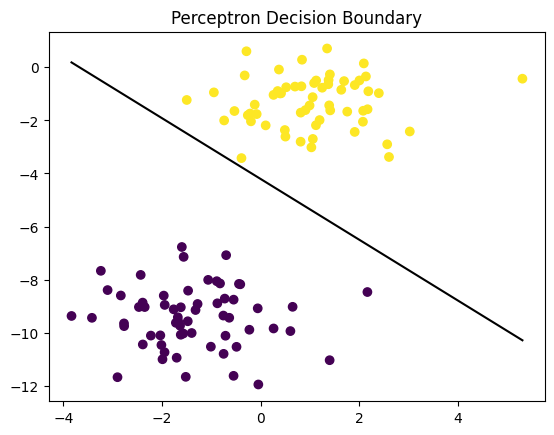

In [ ]:
import numpy as np

class Perceptron:
    def __init__(self, learning_rate=0.01, n_iters=1000):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.activation_func = self._unit_step_func
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape

        # Step 1: Initialize weights and bias to zeros
        self.weights = np.zeros(n_features)
        self.bias = 0

        # Step 2: Ensure target labels are 0 or 1
        y_ = np.array([1 if i > 0 else 0 for i in y])

        # Step 3: Optimization (Weight Update Rule)
        for _ in range(self.n_iters):
            for idx, x_i in enumerate(X):
                linear_output = np.dot(x_i, self.weights) + self.bias
                y_predicted = self.activation_func(linear_output)

                # Perceptron Update Rule:
                # weight = weight + learning_rate * (target - prediction) * input
                update = self.lr * (y_[idx] - y_predicted)

                self.weights += update * x_i
                self.bias += update

    def predict(self, X):
        linear_output = np.dot(X, self.weights) + self.bias
        y_predicted = self.activation_func(linear_output)
        return y_predicted

    def _unit_step_func(self, x):
        return np.where(x >= 0, 1, 0)

# --- Example Usage with Linearly Separable Data ---
if __name__ == "__main__":
    from sklearn.model_selection import train_test_split
    from sklearn import datasets
    import matplotlib.pyplot as plt

    # Generate a synthetic dataset
    X, y = datasets.make_blobs(n_samples=150, n_features=2, centers=2, cluster_std=1.05, random_state=2)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

    # Initialize and train
    p = Perceptron(learning_rate=0.01, n_iters=1000)
    p.fit(X_train, y_train)
    predictions = p.predict(X_test)

    # Check accuracy
    accuracy = np.sum(y_test == predictions) / len(y_test)
    print(f"Perceptron Classification Accuracy: {accuracy * 100:.2f}%")

    # Visualizing the Decision Boundary
    fig = plt.figure()
    ax = fig.add_subplot(1,1,1)
    plt.scatter(X_train[:,0], X_train[:,1], marker='o', c=y_train)

    x0_1 = np.amin(X_train[:,0])
    x0_2 = np.amax(X_train[:,0])

    # Solving for x1: w0x0 + w1x1 + b = 0  => x1 = -(w0x0 + b) / w1
    x1_1 = (-p.weights[0] * x0_1 - p.bias) / p.weights[1]
    x1_2 = (-p.weights[0] * x0_2 - p.bias) / p.weights[1]

    ax.plot([x0_1, x0_2], [x1_1, x1_2], 'k')
    plt.title("Perceptron Decision Boundary")
    plt.show()